# KKBox Data Exploration

In [1]:
import pandas as pd
import numpy as np

## 1. Load Datasets

In [2]:
train = pd.read_csv("../raw_data/train.csv")
members = pd.read_csv("../raw_data/members.csv")
transactions = pd.read_csv("../raw_data/transactions.csv")

### 1.1 Table Overview

In [30]:
train.head()

,msno,is_churn
0,waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1
1,QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1
2,fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1
3,mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1
4,XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1


In [31]:
members.head()

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [20]:
transactions.head()

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,YyO+tlZtAXYXoZhNr3Vg3+dfVQvrBVGO8j1mfqe4ZHc=,41,30,129,129,1,20150930,20151101,0
1,AZtu6Wl0gPojrEQYB8Q3vBSmE2wnZ3hi1FbK1rQQ0A4=,41,30,149,149,1,20150930,20151031,0
2,UkDFI97Qb6+s2LWcijVVv4rMAsORbVDT2wNXF0aVbns=,41,30,129,129,1,20150930,20160427,0
3,M1C56ijxozNaGD0t2h68PnH2xtx5iO5iR2MVYQB6nBI=,39,30,149,149,1,20150930,20151128,0
4,yvj6zyBUaqdbUQSrKsrZ+xNDVM62knauSZJzakS9OW4=,39,30,149,149,1,20150930,20151121,0


## 2. Exploratory Data Analysis

In [21]:
print(f"Shape of Train: {train.shape}")
print(f"Shape of Members: {members.shape}")
print(f"Shape of Transactions: {transactions.shape}")

Shape of Train: (992931, 2)
Shape of Members: (6769473, 6)
Shape of Transactions: (21547746, 9)


### 2.1 Check Churn Rate

In [23]:
train["is_churn"].value_counts()

is_churn
0    929460
1     63471
Name: count, dtype: int64

In [24]:
train["is_churn"].value_counts(normalize=True)

is_churn
0    0.936077
1    0.063923
Name: proportion, dtype: float64

### 2.2 Check Uniqueness

In [25]:
train["msno"].nunique()

992931

In [26]:
len(train)

992931

Each row in train corresponds to one customer.

In [27]:
transactions["msno"].nunique()

2363626

2,363,626 unique customers

In [28]:
len(transactions)

21547746

21,547,746 transaction records

So, each custormer appears multiple times in the transaction table!

## 3. Plots

### 3.1 Churn Distribution

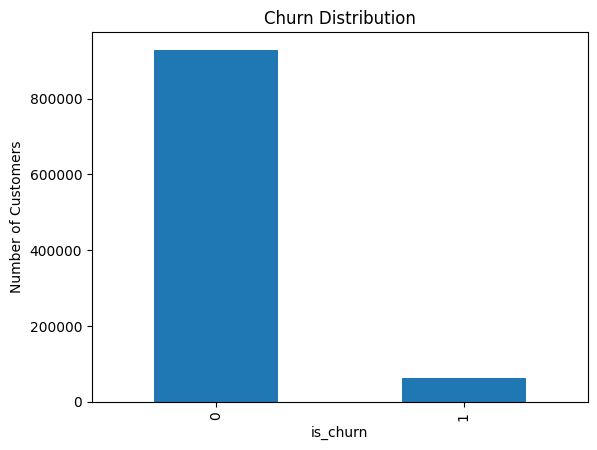

In [29]:
import matplotlib.pyplot as plt

train["is_churn"].value_counts().plot(
    kind="bar"
)

plt.title("Churn Distribution")
plt.xlabel("is_churn")
plt.ylabel("Number of Customers")
plt.show()

### 3.2 Gender Distribution

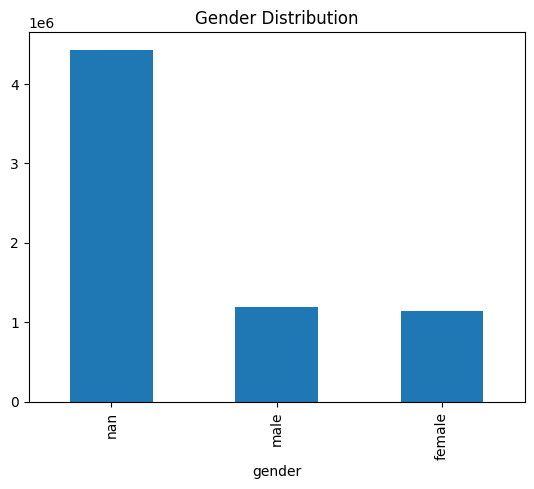

In [30]:
members["gender"].value_counts(dropna=False).plot(
    kind="bar"
)

plt.title("Gender Distribution")
plt.show()

### 3.3 Registration Channel

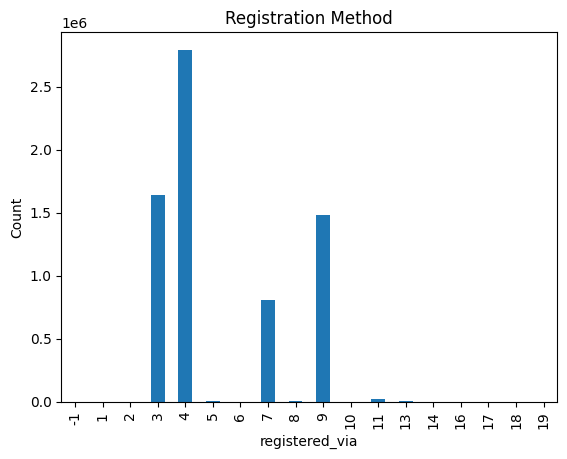

In [31]:
members["registered_via"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Registration Method")
plt.xlabel("registered_via")
plt.ylabel("Count")
plt.show()

### 3.4 Subscription Plan Lenght

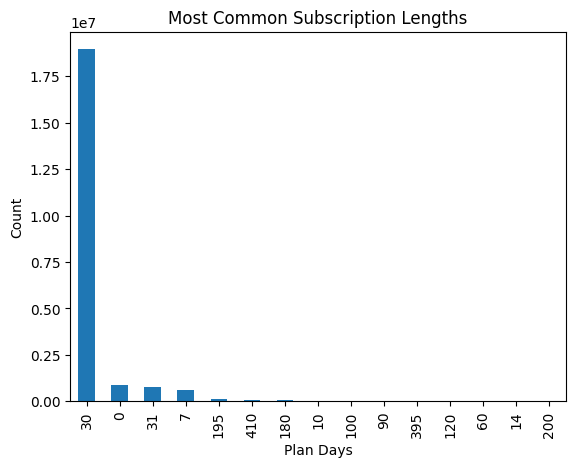

In [32]:
transactions["payment_plan_days"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Most Common Subscription Lengths")
plt.xlabel("Plan Days")
plt.ylabel("Count")
plt.show()

### 3.5 Auto-Renew vs Cancellation

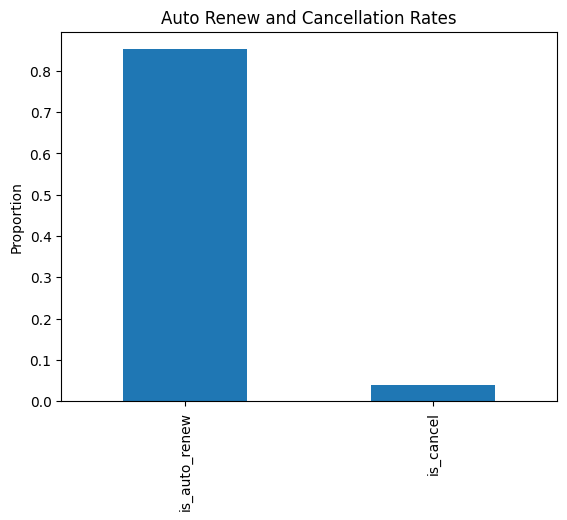

In [33]:
transactions[["is_auto_renew", "is_cancel"]].mean().plot(
    kind="bar"
)

plt.title("Auto Renew and Cancellation Rates")
plt.ylabel("Proportion")
plt.show()

## 4. Baseline Model 1

### Step 1: Merge `train` and `members`

In [3]:
df = train.merge(members, on="msno", how="left")

### Step 2: Basic cleaning

In [4]:
df["registration_init_time"] = pd.to_datetime(
    df["registration_init_time"], format="%Y%m%d"
)

df["registration_year"] = df["registration_init_time"].dt.year
df["registration_month"] = df["registration_init_time"].dt.month

### Step 3: Choose X and y

In [28]:
y = df["is_churn"]

In [6]:
X = df[
    [
        "city",
        "bd",
        "gender",
        "registered_via",
        "registration_year",
        "registration_month"
    ]
]

### Step 4: Numeric and categorical columns

In [7]:
numeric_features = ["bd", "registration_year", "registration_month"]

categorical_features = ["city", "gender", "registered_via"]

### Step 5: Preprocessing

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### Step 6: Train/test split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Step 7: Baseline model

In [10]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

### Step 8: Train

In [11]:
baseline_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Step 9: Evaluate

In [12]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.97      0.67      0.79    185893
           1       0.12      0.65      0.20     12694

    accuracy                           0.67    198587
   macro avg       0.54      0.66      0.50    198587
weighted avg       0.91      0.67      0.75    198587

ROC-AUC: 0.6885512509275324


## 5. Baseline Model 2

Goal:
- keep `members` features and add `transactions` features
- same model, better/more features

### Step 1: Understand transactions

Problem:
- `members` has one row per customer
- `transactions` has many rows per customer

In [16]:
n_transactions = transactions["msno"].nunique()
n_rows = len(transactions)

print(f"Number of transactions: {n_transactions}")
print(f"Number of rows: {n_rows}")
print(f"Transactions per customer: {n_rows/n_transactions}")

Number of transactions: 2363626
Number of rows: 21547746
Transactions per customer: 9.116394048804676


### Step 2: Take only latest transaction

In [ ]:
transactions = transactions.sort_values("transaction_date")

In [22]:
latest_transactions = (transactions.groupby("msno").tail(1).copy())

In [23]:
len(latest_transactions)

2363626

### Step 3: Create features

In [24]:
cols = [
    "msno",
    "payment_method_id",
    "payment_plan_days",
    "plan_list_price",
    "actual_amount_paid",
    "is_auto_renew",
    "is_cancel",
    "membership_expire_date",
    "transaction_date"
]

### Step 4: Convert dates

In [25]:
latest_transactions["transaction_date"] = pd.to_datetime(
    latest_transactions["transaction_date"],
    format="%Y%m%d"
)

latest_transactions["membership_expire_date"] = pd.to_datetime(
    latest_transactions["membership_expire_date"],
    format="%Y%m%d"
)

### Step 5: Create `days_until_expiry` feature

In [26]:
latest_transactions["days_until_expiry"] = (
    latest_transactions["membership_expire_date"]
    -
    latest_transactions["transaction_date"]
).dt.days

### Step 6: Merge dataset

In [42]:
df_2 = df.merge(
    latest_transactions,
    on="msno",
    how="left"
)

### Step 7: Choose X

In [ ]:
X_2 = df_2[
    [
        "city",
        "bd",
        "gender",
        "registered_via",
        "registration_year",
        "registration_month",
        "payment_method_id",
        "payment_plan_days",
        "plan_list_price",
        "actual_amount_paid",
        "is_auto_renew",
        "is_cancel",
        "days_until_expiry"
    ]
]

### Step 8: Update numeric/categorical lists

In [65]:
numeric_features_2 = [
    "bd",
    "registration_year",
    "registration_month",
    "payment_plan_days",
    "plan_list_price",
    "actual_amount_paid",
    "days_until_expiry"
]

In [66]:
categorical_features_2 = [
    "city",
    "gender",
    "registered_via",
    "payment_method_id",
    "is_auto_renew",
    "is_cancel"
]

### Step 9: Preprocessor

In [67]:
preprocessor_2 = ColumnTransformer([
    ("num", numeric_transformer, numeric_features_2),
    ("cat", categorical_transformer, categorical_features_2)
])

### Step 10: Train/test split

In [68]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_2,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Step 11: Baseline model

In [69]:
from sklearn.linear_model import LogisticRegression

baseline_model_2 = Pipeline([
    ("preprocessor", preprocessor_2),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

### Step 12: Train

In [70]:
baseline_model_2.fit(X_train_2, y_train_2)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Step 13: Evaluate

In [71]:
y_pred_2 = baseline_model_2.predict(X_test_2)
y_proba_2 = baseline_model_2.predict_proba(X_test_2)[:, 1]

print(classification_report(y_test_2, y_pred_2))
print("ROC-AUC:", roc_auc_score(y_test_2, y_proba_2))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    185893
           1       0.42      0.96      0.59     12694

    accuracy                           0.91    198587
   macro avg       0.71      0.94      0.77    198587
weighted avg       0.96      0.91      0.93    198587

ROC-AUC: 0.9655469175705589


### Check effect of `is_cancel` and `is_auto_renew`

In [50]:
print(df_2["is_cancel"].value_counts(dropna=False))
print()
print(pd.crosstab(df_2["is_cancel"], df_2["is_churn"]))

is_cancel
0    961331
1     31600
Name: count, dtype: int64

is_churn        0      1
is_cancel               
0          922299  39032
1            7161  24439


In [51]:
print(df_2["is_auto_renew"].value_counts(dropna=False))
print()
print(pd.crosstab(df_2["is_auto_renew"], df_2["is_churn"]))

is_auto_renew
1    882714
0    110217
Name: count, dtype: int64

is_churn            0      1
is_auto_renew               
0               74154  36063
1              855306  27408


### Check importace of each feature

In [72]:
feature_names = baseline_model_2.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = baseline_model_2.named_steps[
    "classifier"
].coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients
})

importance_df["abs_coef"] = importance_df["coef"].abs()

importance_df.sort_values(
    "abs_coef",
    ascending=False
).head(20)

,feature,coef,abs_coef
71,cat__is_cancel_1,4.309588,4.309588
5,num__actual_amount_paid,-3.560001,3.560001
4,num__plan_list_price,3.473161,3.473161
70,cat__is_cancel_0,-3.297155,3.297155
61,cat__payment_method_id_35,2.532662,2.532662
68,cat__is_auto_renew_0,2.441487,2.441487
60,cat__payment_method_id_34,-2.167477,2.167477
67,cat__payment_method_id_41,-2.113134,2.113134
34,cat__registered_via_13.0,-1.848330,1.848330
57,cat__payment_method_id_31,-1.610746,1.610746


In [73]:
importance_df[
    importance_df["feature"].str.contains("days_until_expiry")
]

,feature,coef,abs_coef
6,num__days_until_expiry,0.031118,0.031118
